In [1]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio.transform
import pyproj

In [2]:
# bitmasks for 8-connected neighborhood directions
connected_NW = np.uint8(0b00000001)
connected_N  = np.uint8(0b00000010)
connected_NE = np.uint8(0b00000100)
connected_W  = np.uint8(0b00001000)
connected_E  = np.uint8(0b00010000)
connected_SW = np.uint8(0b00100000)
connected_S  = np.uint8(0b01000000)
connected_SE = np.uint8(0b10000000)

In [13]:
def any_step(i1, j1, i2, j2):
    if graph[i2, j2] & connected_NW:
        i3, j3 = i2 - 1, j2 - 1
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_N:
        i3, j3 = i2 - 1, j2
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_NE:
        i3, j3 = i2 - 1, j2 + 1
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_W:
        i3, j3 = i2, j2 - 1
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_E:
        i3, j3 = i2, j2 + 1
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_SW:
        i3, j3 = i2 + 1, j2 - 1
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_S:
        i3, j3 = i2 + 1, j2
        if (i3, j3) != (i1, j1):
            return i3, j3
    if graph[i2, j2] & connected_SE:
        i3, j3 = i2 + 1, j2 + 1
        if (i3, j3) != (i1, j1):
            return i3, j3
    raise Exception(f"dead end {(i1, j1) = } {(i2, j2) = }")

In [4]:
with rasterio.open("../data/gully-pass3/Dutch Bill Creek-pass3-graph.tif") as file:
    graph = file.read(1)
    index_to_crs = file.transform
    crs_to_lonlat = pyproj.Transformer.from_crs(file.crs, "EPSG:4326", always_xy=True)
    def index_to_lonlat(i, j):
        return crs_to_lonlat.transform(*rasterio.transform.xy(index_to_crs, i, j))

In [5]:
num_connections = np.unpackbits(graph).reshape(graph.shape + (8,)).sum(axis=-1)

In [6]:
line_seeds = np.dstack(np.nonzero(num_connections == 1))[0]

In [53]:
lines = []
for which_line in range(len(line_seeds)):
    i1 = int(line_seeds[which_line, 0])
    j1 = int(line_seeds[which_line, 1])
    line = []
    line.append([i1, j1])
    i2, j2 = any_step(i1, j1, i1, j1)
    line.append([i2, j2])
    while num_connections[i2, j2] == 2:
        i3, j3 = any_step(i1, j1, i2, j2)
        line.append([i3, j3])
        i1, j1 = i2, j2
        i2, j2 = i3, j3

    if len(line) > 500:
        break

len(line)

713

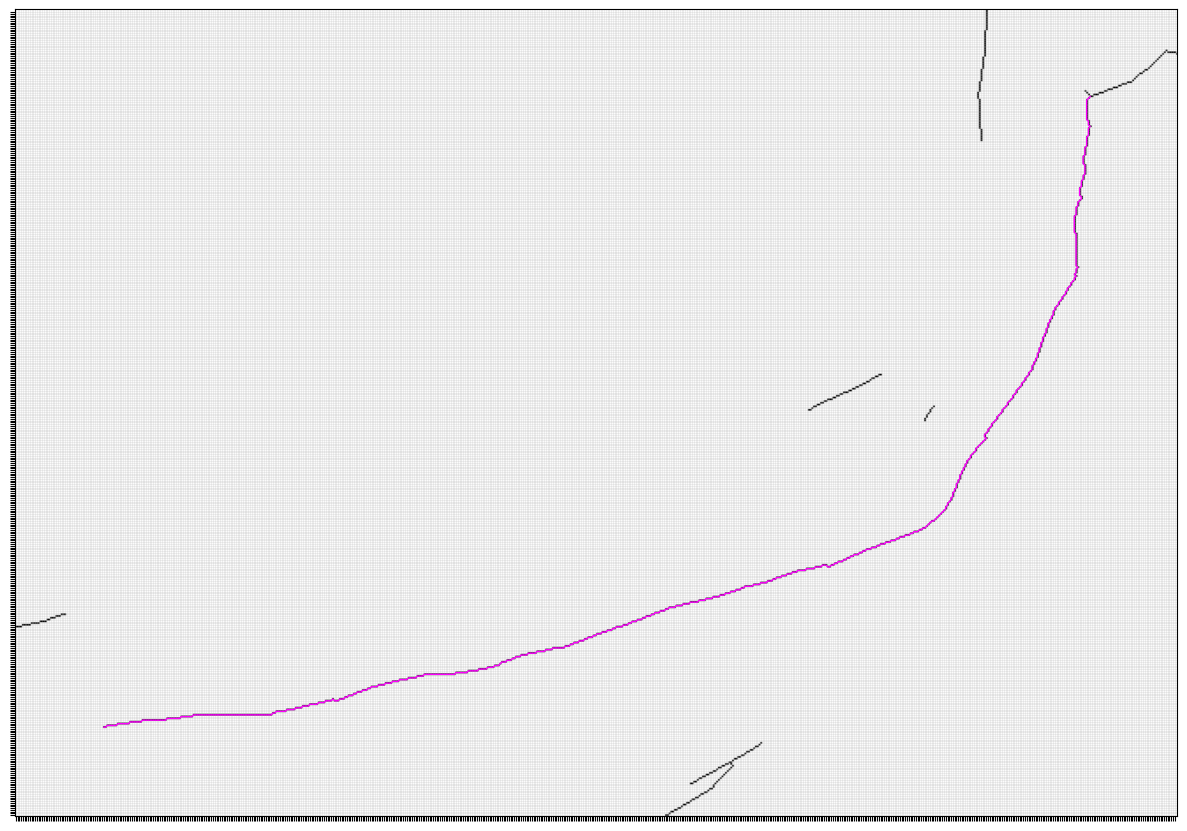

In [58]:
fig, ax = plt.subplots(figsize=(15, 15))

minx = min(x for x, y in line) - 50
maxx = max(x for x, y in line) + 50
miny = min(y for x, y in line) - 50
maxy = max(y for x, y in line) + 50

ax.imshow(graph[minx:maxx, miny:maxy] != 0, cmap="gray_r", origin="lower")
ax.plot([y - miny for x, y in line], [x - minx for x, y in line], linewidth=1, c="magenta")

ax.tick_params(axis="both", which="minor", length=0)
ax.set_xticks(range(*map(int, ax.get_xlim())))
ax.set_yticks(range(*map(int, ax.get_ylim())))
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(which="major", alpha=0.2)

None